In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.ensemble import(GradientBoostingClassifier, HistGradientBoostingClassifier)

from sklearn.gaussian_process import GaussianProcessClassifier

from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


In [ ]:
!pip -q install imbalanced-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

stroke_df = pd.read_csv("/content/drive/MyDrive/project3/healthcare-dataset-stroke-data.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Shape :", df.shape)

stroke_df.head()

Dataset Loaded Successfully
Shape : (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# Display dataset shape, data types,
# missing values and sample records.

print("="*60)
print("Dataset Shape")
print("="*60)

print(stroke_df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

stroke_df.info()

print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(stroke_df.isnull().sum())

Dataset Shape
(5110, 12)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Missing Values
id                     0
gender                 0
age                    0
hypertension      

In [ ]:
# Remove unnecessary columns and
# fill missing BMI values.

# Remove ID column
stroke_df.drop("id", axis=1, inplace=True)

# Fill missing BMI values using median
stroke_df["bmi"] = stroke_df["bmi"].fillna(stroke_df["bmi"].median())

print("="*60)
print("Data Cleaning Completed")
print("="*60)
stroke_df.head()

Data Cleaning Completed


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# Convert categorical features into
# numerical values.

encoder = LabelEncoder()
categorical_columns = [
       "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"]

for column in categorical_columns:
    stroke_df[column] = encoder.fit_transform(stroke_df[column])

print("="*60)
print("Categorical Features Encoded")
print("="*60)
stroke_df.head()

Categorical Features Encoded


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [ ]:
# Display statistical summary.

stroke_df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,5110.0,0.414286,0.493044,0.00,0.000,0.000,1.00,2.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
ever_married,5110.0,0.656164,0.475034,0.00,0.000,1.000,1.00,1.00
work_type,5110.0,2.167710,1.090293,0.00,2.000,2.000,3.00,4.00
Residence_type,5110.0,0.508023,0.499985,0.00,0.000,1.000,1.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,5110.0,28.862035,7.699562,10.30,23.800,28.100,32.80,97.60
smoking_status,5110.0,1.376908,1.071534,0.00,0.000,2.000,2.00,3.00


In [ ]:
# Separate input features and target.

X = stroke_df.drop("stroke", axis=1)
y = stroke_df["stroke"]
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5110, 10)
Target Shape : (5110,)


In [ ]:
# Split dataset and standardize features.

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("="*60)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

print("="*60)

Training Samples : 4088
Testing Samples : 1022


In [ ]:
# Balance the training dataset so that the
# machine learning models learn both classes.

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train,y_train)

print("="*60)
print("Training Data Balanced Successfully")
print("="*60)

print("\nBefore SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_balanced).value_counts())

Training Data Balanced Successfully

Before SMOTE
stroke
0    3889
1     199
Name: count, dtype: int64

After SMOTE
stroke
0    3889
1    3889
Name: count, dtype: int64


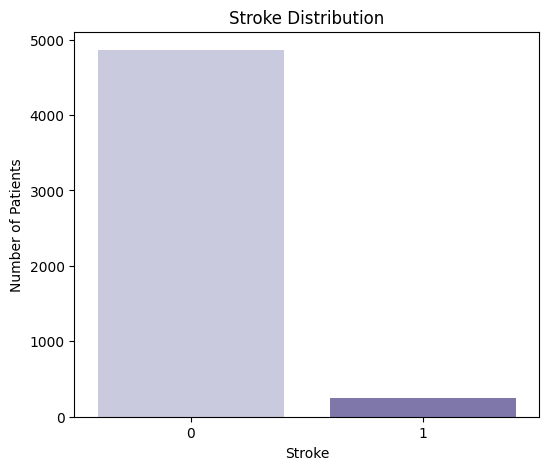

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=stroke_df, x="stroke",
    hue="stroke",
    palette="Purples",
    legend=False
)

plt.title("Stroke Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Patients")

plt.show()

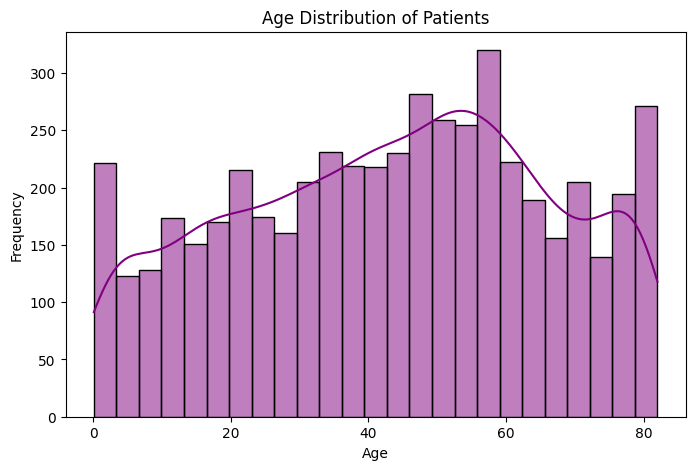

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    stroke_df["age"],
    bins=25,
    kde=True,
    color="purple")

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

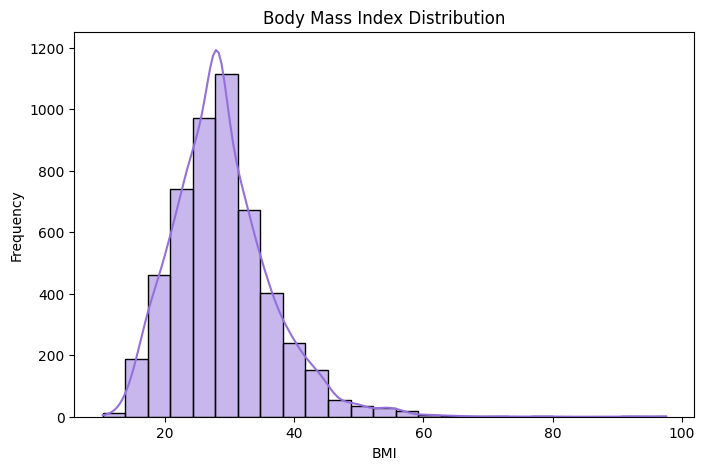

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    stroke_df["bmi"],
    bins=25,
    kde=True,
    color="mediumpurple")

plt.title("Body Mass Index Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

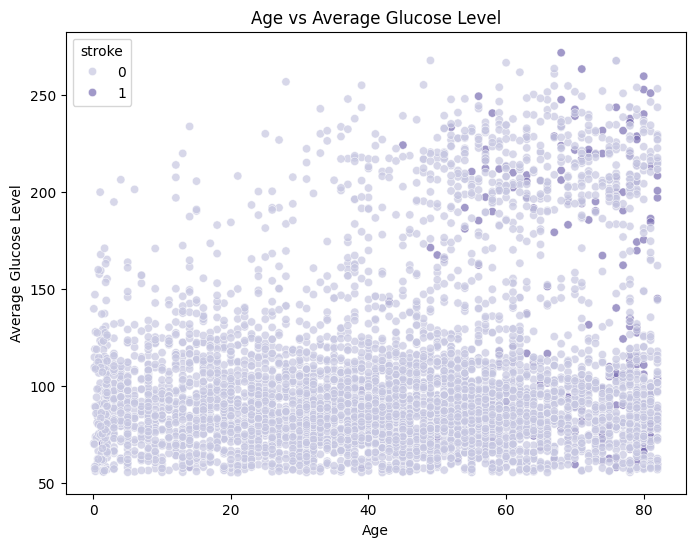

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=stroke_df,
    x="age",
    y="avg_glucose_level",
    hue="stroke",
    palette="Purples",
    alpha=0.7)

plt.title("Age vs Average Glucose Level")
plt.xlabel("Age")
plt.ylabel("Average Glucose Level")
plt.show()

In [ ]:
# Train the Gradient Boosting model using the
# balanced training dataset and evaluate its performance.

gb_model = GradientBoostingClassifier(n_estimators=150,learning_rate=0.05,random_state=42)
gb_model.fit(X_train_balanced,y_train_balanced)
gb_prediction = gb_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_prediction)
gb_precision = precision_score(y_test, gb_prediction)
gb_recall = recall_score(y_test, gb_prediction)
gb_f1 = f1_score(y_test, gb_prediction)
gb_auc = roc_auc_score(y_test, gb_prediction)

print("="*60)
print("Gradient Boosting Classifier Results")
print("="*60)
print("Accuracy :", round(gb_accuracy*100,2), "%")
print("Precision :", round(gb_precision,3))
print("Recall :", round(gb_recall,3))
print("F1 Score :", round(gb_f1,3))
print("ROC AUC :", round(gb_auc,3))

Gradient Boosting Classifier Results
Accuracy : 85.81 %
Precision : 0.19
Recall : 0.58
F1 Score : 0.286
ROC AUC : 0.726


In [ ]:
# Train the HistGradientBoosting model using
# the balanced training dataset.

hgb_model = HistGradientBoostingClassifier(max_iter=250,learning_rate=0.05,random_state=42)
hgb_model.fit(X_train_balanced,y_train_balanced)
hgb_prediction = hgb_model.predict(X_test)
hgb_accuracy = accuracy_score(y_test, hgb_prediction)
hgb_precision = precision_score(y_test, hgb_prediction)
hgb_recall = recall_score(y_test, hgb_prediction)
hgb_f1 = f1_score(y_test, hgb_prediction)
hgb_auc = roc_auc_score(y_test, hgb_prediction)

print("="*60)
print("HistGradientBoosting Classifier Results")
print("="*60)
print("Accuracy :", round(hgb_accuracy*100,2), "%")
print("Precision :", round(hgb_precision,3))
print("Recall :", round(hgb_recall,3))
print("F1 Score :", round(hgb_f1,3))
print("ROC AUC :", round(hgb_auc,3))

HistGradientBoosting Classifier Results
Accuracy : 92.47 %
Precision : 0.213
Recall : 0.2
F1 Score : 0.206
ROC AUC : 0.581


In [ ]:
# Train the Bagging Classifier using the
# balanced training dataset.

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),n_estimators=100,random_state=42,n_jobs=-1)
bag_model.fit(X_train_balanced, y_train_balanced)
bag_prediction = bag_model.predict(X_test)
bag_accuracy = accuracy_score(y_test, bag_prediction)
bag_precision = precision_score(y_test, bag_prediction)
bag_recall = recall_score(y_test, bag_prediction)
bag_f1 = f1_score(y_test, bag_prediction)
bag_auc = roc_auc_score(y_test, bag_prediction)

print("="*60)
print("Bagging Classifier Results")
print("="*60)

print("Accuracy :", round(bag_accuracy*100,2), "%")
print("Precision :", round(bag_precision,3))
print("Recall :", round(bag_recall,3))
print("F1 Score :", round(bag_f1,3))
print("ROC AUC :", round(bag_auc,3))

Bagging Classifier Results
Accuracy : 92.27 %
Precision : 0.163
Recall : 0.14
F1 Score : 0.151
ROC AUC : 0.551


In [ ]:
# Train the MLP Neural Network
# using the balanced training dataset.

mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", learning_rate_init=0.001, max_iter=500, random_state=42)
mlp_model.fit(X_train_balanced, y_train_balanced)
mlp_prediction = mlp_model.predict(X_test)
mlp_accuracy = accuracy_score(y_test, mlp_prediction)
mlp_precision = precision_score(y_test, mlp_prediction)
mlp_recall = recall_score(y_test, mlp_prediction)
mlp_f1 = f1_score(y_test, mlp_prediction)
mlp_auc = roc_auc_score(y_test, mlp_prediction)

print("="*60)
print("MLP Neural Network Results")
print("="*60)

print("Accuracy :", round(mlp_accuracy*100,2), "%")
print("Precision :", round(mlp_precision,3))
print("Recall :", round(mlp_recall,3))
print("F1 Score :", round(mlp_f1,3))
print("ROC AUC :", round(mlp_auc,3))

MLP Neural Network Results
Accuracy : 88.45 %
Precision : 0.13
Recall : 0.24
F1 Score : 0.169
ROC AUC : 0.579


In [ ]:
# Compare all machine learning models
# using multiple evaluation metrics.

# Train the Gaussian Process Classifier to define gpc_* metrics
gpc_model = GaussianProcessClassifier(random_state=42)
gpc_model.fit(X_train_balanced, y_train_balanced)
gpc_prediction = gpc_model.predict(X_test)

gpc_accuracy = accuracy_score(y_test, gpc_prediction)
gpc_precision = precision_score(y_test, gpc_prediction)
gpc_recall = recall_score(y_test, gpc_prediction)
gpc_f1 = f1_score(y_test, gpc_prediction)
gpc_auc = roc_auc_score(y_test, gpc_prediction)

results = pd.DataFrame({

    "Model": [
        "Gradient Boosting",
        "HistGradientBoosting",
        "Gaussian Process",
        "MLP Neural Network"],

    "Accuracy (%)": [
        gb_accuracy*100,
        hgb_accuracy*100,
        gpc_accuracy*100,
        mlp_accuracy*100],

    "Precision": [
        gb_precision,
        hgb_precision,
        gpc_precision,
        mlp_precision],

    "Recall": [
        gb_recall,
        hgb_recall,
        gpc_recall,
        mlp_recall],

    "F1 Score": [
        gb_f1,
        hgb_f1,
        gpc_f1,
        mlp_f1],

    "ROC AUC": [
        gb_auc,
        hgb_auc,
        gpc_auc,
        mlp_auc]})

results = results.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print(results)
results

                  Model  Accuracy (%)  Precision  Recall  F1 Score   ROC AUC
0     Gradient Boosting     85.812133   0.189542    0.58  0.285714  0.726214
1  HistGradientBoosting     92.465753   0.212766    0.20  0.206186  0.580967
2      Gaussian Process     79.745597   0.113300    0.46  0.181818  0.637407
3    MLP Neural Network     88.454012   0.130435    0.24  0.169014  0.578848


,Model,Accuracy (%),Precision,Recall,F1 Score,ROC AUC
0,Gradient Boosting,85.812133,0.189542,0.58,0.285714,0.726214
1,HistGradientBoosting,92.465753,0.212766,0.20,0.206186,0.580967
2,Gaussian Process,79.745597,0.113300,0.46,0.181818,0.637407
3,MLP Neural Network,88.454012,0.130435,0.24,0.169014,0.578848


In [ ]:
best_model = results.iloc[0]

print("="*60)
print("Best Machine Learning Model")
print("="*60)

print(best_model)

Best Machine Learning Model
Model           Gradient Boosting
Accuracy (%)            85.812133
Precision                0.189542
Recall                       0.58
F1 Score                 0.285714
ROC AUC                  0.726214
Name: 0, dtype: object


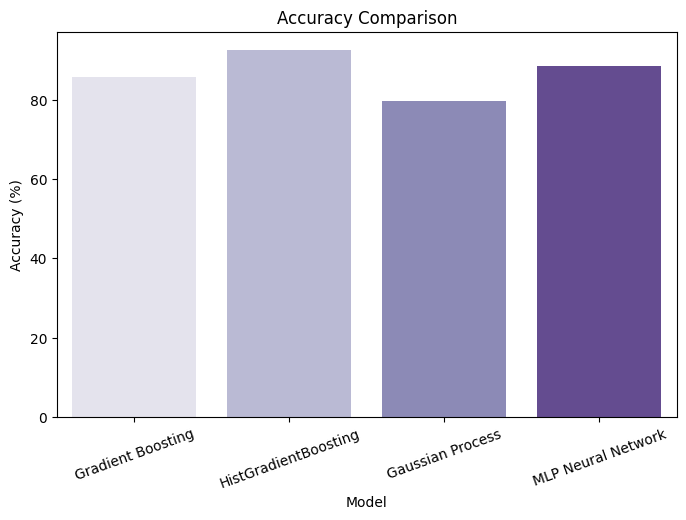

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)",
    palette="Purples")

plt.xticks(rotation=20)
plt.title("Accuracy Comparison")
plt.show()

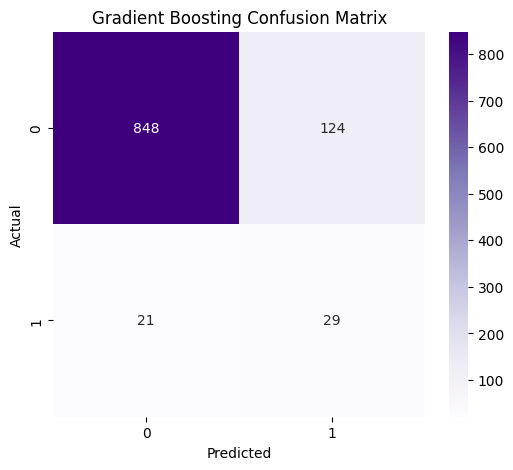

In [ ]:
cm = confusion_matrix(y_test, gb_prediction)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples")

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:

print(classification_report(y_test, gb_prediction))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92       972
           1       0.19      0.58      0.29        50

    accuracy                           0.86      1022
   macro avg       0.58      0.73      0.60      1022
weighted avg       0.94      0.86      0.89      1022



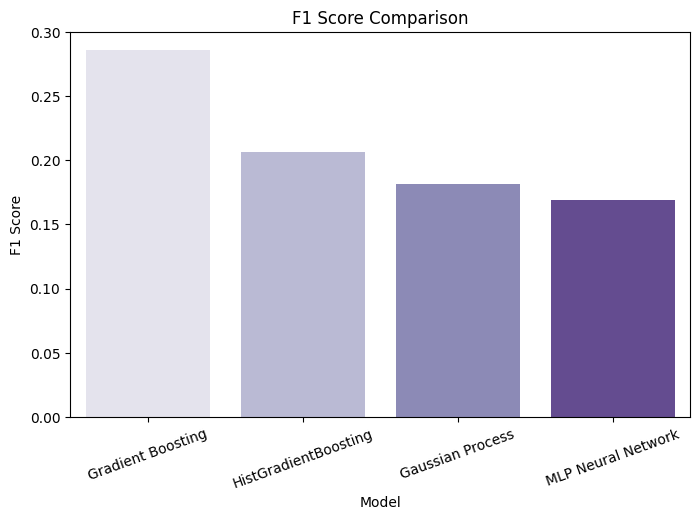

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=results,
    x="Model",
    y="F1 Score",
    palette="Purples")

plt.xticks(rotation=20)
plt.title("F1 Score Comparison")
plt.show()

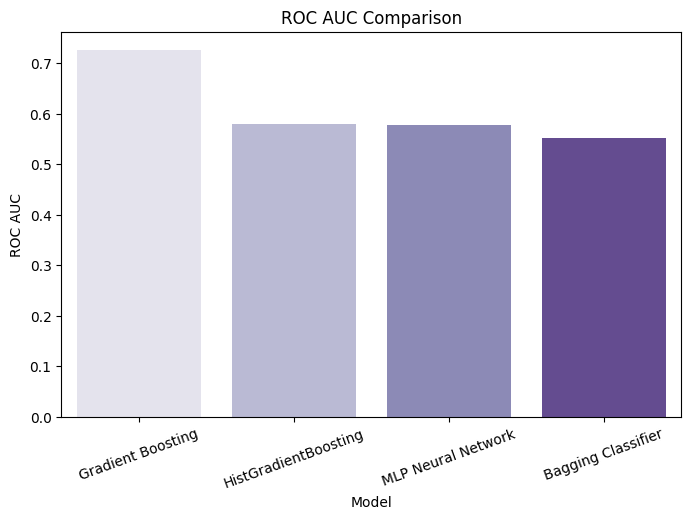

In [ ]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="ROC AUC",
    palette="Purples")
plt.xticks(rotation=20)
plt.title("ROC AUC Comparison")
plt.show()

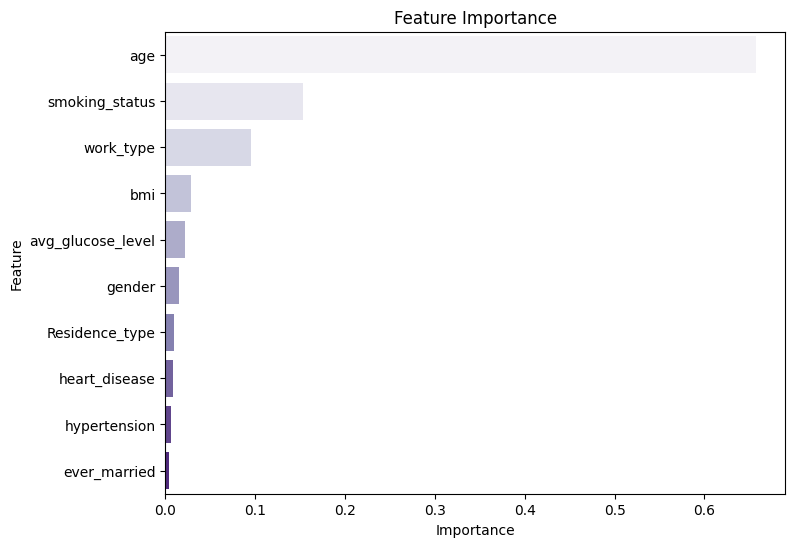

In [ ]:
importance = pd.DataFrame({"Feature":X.columns,"Importance":gb_model.feature_importances_})

importance = importance.sort_values(
    by="Importance",
    ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="Purples")

plt.title("Feature Importance")
plt.show()

In [ ]:
importance.head(10)

,Feature,Importance
1,age,0.657054
9,smoking_status,0.153320
5,work_type,0.095440
8,bmi,0.028900
7,avg_glucose_level,0.022432
0,gender,0.015550
6,Residence_type,0.009574
3,heart_disease,0.008083
2,hypertension,0.005995
4,ever_married,0.003654


In [ ]:
print("="*60)
print("Stroke Prediction Using Machine Learning")
print("="*60)

print("Dataset Shape :", df.shape)
print("\nModels Used:")

for model in results["Model"]:
    print("-",model)

print("\nBest Model :",results.iloc[0]["Model"])
print("Best Accuracy :",round(results.iloc[0]["Accuracy (%)"],2),"%")
print("Best F1 Score :",round(results.iloc[0]["F1 Score"],3))
print("="*60)

Stroke Prediction Using Machine Learning
Dataset Shape : (5110, 12)

Models Used:
- Gradient Boosting
- HistGradientBoosting
- Gaussian Process
- MLP Neural Network

Best Model : Gradient Boosting
Best Accuracy : 85.81 %
Best F1 Score : 0.286
